In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = '/content/drive/MyDrive/capflow-analytics'

folders = [
    'data',
    'notebooks',
    'models',
    'reports/validation_charts',
    'metabase',
    'sql',
]

os.makedirs(PROJECT_ROOT, exist_ok=True)

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)
    gitkeep = os.path.join(path, '.gitkeep')
    with open(gitkeep, 'w') as f:
        pass

print("Folder structure created:")
for root, dirs, files in os.walk(PROJECT_ROOT):
    dirs[:] = [d for d in dirs if d != '.git']
    level = root.replace(PROJECT_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

Folder structure created:
capflow-analytics/
  data/
  notebooks/
  models/
  reports/
    validation_charts/
  metabase/
  sql/


In [4]:
from google.colab import userdata

token     = userdata.get('GITHUB_TOKEN')
username  = userdata.get('GITHUB_USERNAME')
email     = userdata.get('GITHUB_EMAIL')
repo_url  = userdata.get('GITHUB_REPO_URL')

os.chdir(PROJECT_ROOT)

!git config --global user.name  "{username}"
!git config --global user.email "{email}"
!git config --global init.defaultBranch main

auth_url = repo_url.replace('https://', f'https://{username}:{token}@')

!git init
!git remote add origin {auth_url}
!git checkout -b main

print("Git initialised and remote set.")

Reinitialized existing Git repository in /content/drive/MyDrive/capflow-analytics/.git/
error: remote origin already exists.
Switched to a new branch 'main'
Git initialised and remote set.


In [6]:
gitignore_content = """# Python
__pycache__/
*.py[cod]
*.pyo
.env

# Jupyter
.ipynb_checkpoints/
*.ipynb_checkpoints

# Data and outputs (keep schema, ignore generated db)
data/*.db
data/*.csv

# Excel outputs
models/*.xlsx

# Metabase
metabase/metabase-data/
metabase/*.db

# OS
.DS_Store
Thumbs.db
"""

requirements_content = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
statsmodels
openpyxl
sqlalchemy
ipykernel
"""

readme_content = """# CapFlow Analytics

Commercial analytics portfolio project built to demonstrate Strategy Analyst capabilities.

## The Scenario

CapFlow is a UK-based embedded finance company providing revenue-based financing to small
businesses through three partner platforms: ShopBase, MarketHub, and RetailCloud.

## Deliverables

| # | Deliverable | Status |
|---|---|---|
| D1 | Variance Decomposition Report | In progress |
| D2 | Partner Performance Dashboard | Not started |
| D3 | MarketHub Conversion Investigation | Not started |
| D4 | Pricing Impact Model | Not started |
| D5 | Commercial Forecast Model | Not started |
| D6 | Written Strategy Brief | Not started |

## Tech Stack

- Python (Pandas, NumPy, Matplotlib, scikit-learn, XGBoost, statsmodels)
- SQLite
- Metabase via Docker
- Excel (openpyxl)
- Google Colab

## Setup

```bash
pip install -r requirements.txt
```

## Structure
capflow-analytics/
├── data/               # SQLite database and raw CSVs
├── notebooks/          # Jupyter notebooks, one per deliverable
├── models/             # Excel pricing and forecast models
├── reports/            # PDFs and charts
├── sql/                # Standalone SQL queries for Metabase
└── metabase/           # Docker config

"""

with open(os.path.join(PROJECT_ROOT, '.gitignore'), 'w') as f:
    f.write(gitignore_content)

with open(os.path.join(PROJECT_ROOT, 'requirements.txt'), 'w') as f:
    f.write(requirements_content)

with open(os.path.join(PROJECT_ROOT, 'README.md'), 'w') as f:
    f.write(readme_content)

print("Files written.")

Files written.


In [10]:
os.chdir(PROJECT_ROOT)

!git add .
!git commit -m "feat: initial project structure, gitignore, requirements, README"
!git push -u origin main

print("Pushed to GitHub.")

[main fa6eab6] feat: initial project structure, gitignore, requirements, README
Enumerating objects: 18, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (13/13), done.
Writing objects: 100% (18/18), 6.23 KiB | 130.00 KiB/s, done.
Total 18 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), done.
To https://github.com/dobadina/capflow-analytics.git
 * [new branch]      main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.
Pushed to GitHub.


In [34]:
os.chdir(PROJECT_ROOT)

!git add .
!git commit -m "fix: rename notebook to capflow_analytics"
!git push

print("Done.")

[main 8322142] fix: rename notebook to capflow_analytics
 1 file changed, 1 insertion(+), 1 deletion(-)
 rename notebooks/{Untitled0.ipynb => capflow_analytics.ipynb} (68%)
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 3.36 KiB | 313.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/dobadina/capflow-analytics.git
   3a404fa..8322142  main -> main
Done.


# Phase 1: Data Generation

Generates all five tables covering 18 months of CapFlow activity and writes them to SQLite.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import sqlite3
from datetime import date, timedelta

np.random.seed(42)

PROJECT_ROOT = '/content/drive/MyDrive/capflow-analytics'

# ── CONFIG ────────────────────────────────────────────────────────────────────

START_DATE = date(2023, 1, 1)
MONTHS     = 18
PARTNERS   = ['ShopBase', 'MarketHub', 'RetailCloud']
SEGMENTS   = ['micro', 'small', 'medium']

LEAD_VOLUME = {
    'ShopBase':    {'micro': 120, 'small': 80, 'medium': 40},
    'MarketHub':   {'micro': 90,  'small': 70,  'medium': 35},
    'RetailCloud': {'micro': 60,  'small': 50,  'medium': 25},
}

BASE_CONVERSION = {
    'ShopBase':    {'micro': 0.30, 'small': 0.38, 'medium': 0.45},
    'MarketHub':   {'micro': 0.32, 'small': 0.40, 'medium': 0.46},
    'RetailCloud': {'micro': 0.28, 'small': 0.36, 'medium': 0.42},
}

AVG_FUNDED = {
    'micro':  5_000,
    'small':  15_000,
    'medium': 35_000,
}

FACTOR_RATES = {
    'micro':  1.28,
    'small':  1.22,
    'medium': 1.18,
}

DEFAULT_RATES = {
    'ShopBase':    {'micro': 0.12, 'small': 0.05, 'medium': 0.02},
    'MarketHub':   {'micro': 0.07, 'small': 0.04, 'medium': 0.02},
    'RetailCloud': {'micro': 0.08, 'small': 0.04, 'medium': 0.02},
}

REPAYMENT_TERMS = {
    'micro':  120,
    'small':  180,
    'medium': 270,
}

# ── HELPERS ───────────────────────────────────────────────────────────────────

def month_start(month_index):
    m = START_DATE.month + month_index
    y = START_DATE.year + (m - 1) // 12
    m = (m - 1) % 12 + 1
    return date(y, m, 1)

def days_in_month(d):
    next_m = date(d.year + (d.month // 12), (d.month % 12) + 1, 1)
    return (next_m - d).days

def markethub_conversion(month_index, segment):
    base = BASE_CONVERSION['MarketHub'][segment]
    if month_index < 12:
        return base
    decay_step = (base - 0.24) / 5
    steps = min(month_index - 12, 5)
    return round(base - decay_step * steps, 4)

def macro_shock_multiplier(month_index):
    if month_index == 13:
        return 0.72
    if month_index == 14:
        return 0.88
    return 1.0

# ── TABLE 1: LEADS ────────────────────────────────────────────────────────────

def generate_leads():
    records = []
    lead_id = 1

    for m in range(MONTHS):
        month_date = month_start(m)
        shock      = macro_shock_multiplier(m)

        for partner in PARTNERS:
            for segment in SEGMENTS:
                base_vol = LEAD_VOLUME[partner][segment]

                if m >= 15:
                    base_vol = int(base_vol * 0.92)

                n_leads = int(base_vol * shock * np.random.uniform(0.93, 1.07))

                if partner == 'MarketHub':
                    conv = markethub_conversion(m, segment)
                else:
                    conv = BASE_CONVERSION[partner][segment]

                conv = conv * (0.95 if shock < 1.0 else 1.0)

                for _ in range(n_leads):
                    rand_day = np.random.randint(0, days_in_month(month_date))
                    app_date = month_date + timedelta(days=rand_day)
                    rand_val = np.random.random()

                    if rand_val < conv:
                        status = 'approved'
                    elif rand_val < conv + 0.15:
                        status = 'withdrawn'
                    else:
                        status = 'declined'

                    records.append({
                        'lead_id':            lead_id,
                        'partner':            partner,
                        'date':               app_date.isoformat(),
                        'merchant_segment':   segment,
                        'application_status': status,
                    })
                    lead_id += 1

    return pd.DataFrame(records)

# ── TABLE 2: FUNDED DEALS ─────────────────────────────────────────────────────

def generate_funded_deals(leads_df):
    approved = leads_df[leads_df['application_status'] == 'approved'].copy()
    records  = []
    deal_id  = 1

    for _, row in approved.iterrows():
        segment = row['merchant_segment']
        partner = row['partner']

        avg    = AVG_FUNDED[segment]
        amount = round(np.random.normal(avg, avg * 0.25), 2)
        amount = max(1_000, amount)

        app_date = date.fromisoformat(row['date'])
        if app_date >= month_start(15) and segment == 'micro':
            amount = round(amount * 0.88, 2)

        funded_date = app_date + timedelta(days=np.random.randint(1, 5))

        records.append({
            'deal_id':             deal_id,
            'lead_id':             row['lead_id'],
            'partner':             partner,
            'funded_amount':       amount,
            'factor_rate':         FACTOR_RATES[segment],
            'repayment_term_days': REPAYMENT_TERMS[segment],
            'funded_date':         funded_date.isoformat(),
            'merchant_segment':    segment,
        })
        deal_id += 1

    return pd.DataFrame(records)

# ── TABLE 3: DEFAULTS ─────────────────────────────────────────────────────────

def generate_defaults(funded_df):
    records = []

    for _, row in funded_df.iterrows():
        rate = DEFAULT_RATES[row['partner']][row['merchant_segment']]
        if np.random.random() < rate:
            funded_date  = date.fromisoformat(row['funded_date'])
            term         = row['repayment_term_days']
            default_day  = int(term * np.random.uniform(0.20, 0.70))
            default_date = funded_date + timedelta(days=default_day)

            total_owed         = round(row['funded_amount'] * row['factor_rate'], 2)
            pct_repaid         = default_day / term
            amount_repaid      = round(total_owed * pct_repaid * np.random.uniform(0.8, 1.0), 2)
            amount_outstanding = round(total_owed - amount_repaid, 2)

            records.append({
                'deal_id':            row['deal_id'],
                'default_date':       default_date.isoformat(),
                'amount_outstanding': amount_outstanding,
            })

    return pd.DataFrame(records)

# ── TABLE 4: REPAYMENTS ───────────────────────────────────────────────────────

def generate_repayments(funded_df, defaults_df):
    default_lookup = set(defaults_df['deal_id'].tolist())
    default_dates  = defaults_df.set_index('deal_id')['default_date'].to_dict()
    records        = []

    for _, row in funded_df.iterrows():
        deal_id     = row['deal_id']
        funded_date = date.fromisoformat(row['funded_date'])
        term        = row['repayment_term_days']
        total_owed  = round(row['funded_amount'] * row['factor_rate'], 2)
        daily_amt   = round(total_owed / term, 2)

        is_default = deal_id in default_lookup
        end_date   = date.fromisoformat(default_dates[deal_id]) if is_default \
                     else funded_date + timedelta(days=term)

        cumulative = 0.0
        current    = funded_date + timedelta(days=1)

        while current <= end_date and cumulative < total_owed:
            jitter     = round(daily_amt * np.random.uniform(0.85, 1.15), 2)
            payment    = min(jitter, round(total_owed - cumulative, 2))
            cumulative = round(cumulative + payment, 2)

            records.append({
                'deal_id':           deal_id,
                'repayment_date':    current.isoformat(),
                'amount_repaid':     payment,
                'cumulative_repaid': cumulative,
            })
            current += timedelta(days=1)

    return pd.DataFrame(records)

# ── TABLE 5: FORECAST ─────────────────────────────────────────────────────────

def generate_forecast():
    records = []

    for m in range(MONTHS):
        month_date = month_start(m)
        month_str  = month_date.strftime('%Y-%m')

        for partner in PARTNERS:
            forecast_leads = sum(LEAD_VOLUME[partner][s] for s in SEGMENTS)

            conv_rates   = [BASE_CONVERSION[partner][s] for s in SEGMENTS]
            forecast_conv = round(np.mean(conv_rates), 4)

            weights      = [LEAD_VOLUME[partner][s] for s in SEGMENTS]
            total_w      = sum(weights)
            forecast_avg = round(
                sum(AVG_FUNDED[s] * w / total_w for s, w in zip(SEGMENTS, weights)), 2
            )

            forecast_volume = round(forecast_leads * forecast_conv * forecast_avg, 2)

            records.append({
                'month':                      month_str,
                'partner':                    partner,
                'forecast_leads':             forecast_leads,
                'forecast_conversion_rate':   forecast_conv,
                'forecast_avg_funded_amount': forecast_avg,
                'forecast_funded_volume':     forecast_volume,
            })

    return pd.DataFrame(records)

# ── GENERATE ──────────────────────────────────────────────────────────────────

print("Generating tables...")

leads_df      = generate_leads()
funded_df     = generate_funded_deals(leads_df)
defaults_df   = generate_defaults(funded_df)
repayments_df = generate_repayments(funded_df, defaults_df)
forecast_df   = generate_forecast()

# ── WRITE TO SQLITE ───────────────────────────────────────────────────────────

db_path = os.path.join(PROJECT_ROOT, 'data/capflow.db')
conn    = sqlite3.connect(db_path)

leads_df.to_sql('leads',        conn, if_exists='replace', index=False)
funded_df.to_sql('funded_deals', conn, if_exists='replace', index=False)
defaults_df.to_sql('defaults',   conn, if_exists='replace', index=False)
repayments_df.to_sql('repayments', conn, if_exists='replace', index=False)
forecast_df.to_sql('forecast',   conn, if_exists='replace', index=False)
conn.close()

print(f"Database written to {db_path}")
print(f"\nRow counts:")
print(f"  leads:        {len(leads_df):,}")
print(f"  funded_deals: {len(funded_df):,}")
print(f"  defaults:     {len(defaults_df):,}")
print(f"  repayments:   {len(repayments_df):,}")
print(f"  forecast:     {len(forecast_df):,}")

# ── VALIDATION ────────────────────────────────────────────────────────────────

print("\nValidating patterns...")

# 1. MarketHub conversion decay
mh = leads_df[leads_df['partner'] == 'MarketHub'].copy()
mh['month'] = pd.to_datetime(mh['date']).dt.to_period('M')
mh_conv = mh.groupby('month').apply(
    lambda x: (x['application_status'] == 'approved').sum() / len(x),
    include_groups=False
).reset_index()
mh_conv.columns = ['month', 'conversion_rate']
early = mh_conv.head(6)['conversion_rate'].mean()
late  = mh_conv.tail(6)['conversion_rate'].mean()
assert late < early, "FAIL: MarketHub conversion should decline in later months"
print(f"  MarketHub conversion: early avg {early:.1%} vs late avg {late:.1%} - OK")

# 2. Macro shock in month 14
funded_df['month'] = pd.to_datetime(funded_df['funded_date']).dt.to_period('M')
monthly_vol = funded_df.groupby('month')['funded_amount'].sum()
m14 = monthly_vol.iloc[13]
m13 = monthly_vol.iloc[12]
m15 = monthly_vol.iloc[14]
assert m14 < m13 and m14 < m15, "FAIL: Month 14 should be lowest of months 13-15"
print(f"  Macro shock month 14: {m14:,.0f} vs month 13: {m13:,.0f} and month 15: {m15:,.0f} - OK")

# 3. ShopBase micro vs medium default rate
sb = funded_df[funded_df['partner'] == 'ShopBase'].copy()
sb = sb.merge(defaults_df[['deal_id']].assign(defaulted=1), on='deal_id', how='left').fillna(0)
micro_dr  = sb[sb['merchant_segment'] == 'micro']['defaulted'].mean()
medium_dr = sb[sb['merchant_segment'] == 'medium']['defaulted'].mean()
assert micro_dr > medium_dr, "FAIL: ShopBase micro default rate should exceed medium"
print(f"  ShopBase default rates: micro {micro_dr:.1%} vs medium {medium_dr:.1%} - OK")

print("\nAll validation checks passed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generating tables...
Database written to /content/drive/MyDrive/capflow-analytics/data/capflow.db

Row counts:
  leads:        9,816
  funded_deals: 3,368
  defaults:     193
  repayments:   571,884
  forecast:     54

Validating patterns...
  MarketHub conversion: early avg 35.9% vs late avg 31.2% - OK
  Macro shock month 14: 2,113,509 vs month 13: 3,011,652 and month 15: 2,589,587 - OK
  ShopBase default rates: micro 11.3% vs medium 2.2% - OK

All validation checks passed.


In [37]:
os.chdir(PROJECT_ROOT)

!git add .
!git commit -m "feat: phase 1 data generation, all tables written to capflow.db"
!git push

print("Done.")

[main 956fa4f] feat: phase 1 data generation, all tables written to capflow.db
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 data/generate_data.py
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 9.01 KiB | 279.00 KiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 1 local object.
To https://github.com/dobadina/capflow-analytics.git
   8322142..956fa4f  main -> main
Done.


## Phase 2: Variance Decomposition

### What this is and why it matters

Last quarter, CapFlow funded £2.1M less than it had forecast. The business knows the number but not the story behind it. This section breaks that gap into its component parts so we can say exactly what caused it and by how much.
The method is called a price-volume-mix decomposition. The idea is straightforward: we isolate each possible cause of the miss one at a time, hold everything else constant, and measure its contribution in pounds. At the end, all the parts add up to the total gap exactly. No rounding, no residual left over.

#### The four drivers we are testing:

- Volume: did fewer merchants apply than expected?
- Conversion: did a lower share of applicants get funded?
- Mix: did the portfolio shift toward smaller deals, pulling the average funded amount down?
- Pricing: did any movement in factor rates affect revenue?

The output is a waterfall chart and a one-page brief that a Head of Commercial can read in two minutes and walk into a board meeting with.

Breaking down the Q4 funded volume miss into its component causes.
Each driver is isolated and measured in pounds so they add up to the total gap exactly.

Q4 Funded Volume Variance Decomposition
  Forecast volume:    £   8,871,854
  Actual volume:      £   7,548,458
  Total gap:          £  -1,323,397  (-14.9%)

Driver breakdown:
  Volume effect:      £    -830,083  (-9.4%)
  Conversion effect:  £    -947,334  (-10.7%)
  Mix effect:         £     558,997  (6.3%)
  Pricing effect:     £    -104,977  (-1.2%)

  Sum of drivers:     £  -1,323,397
  Matches total gap:  Yes


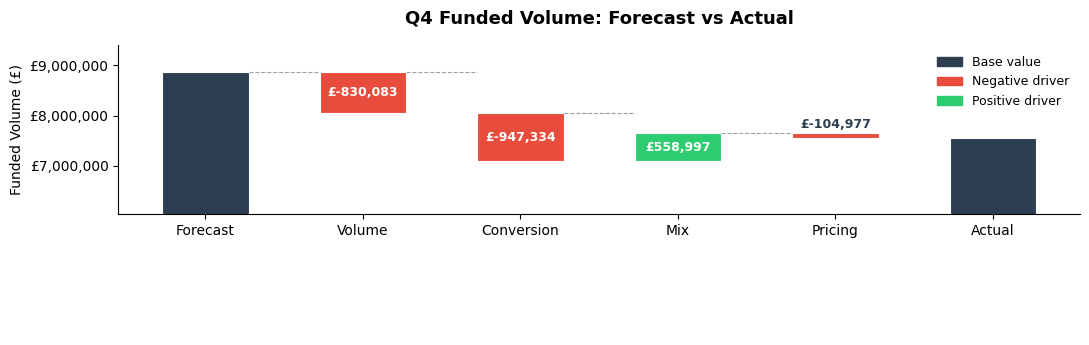

Chart saved to /content/drive/MyDrive/capflow-analytics/reports/validation_charts/q4_waterfall.png


In [48]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

PROJECT_ROOT = '/content/drive/MyDrive/capflow-analytics'
db_path      = os.path.join(PROJECT_ROOT, 'data/capflow.db')

conn        = sqlite3.connect(db_path)
leads_df    = pd.read_sql('SELECT * FROM leads',        conn)
funded_df   = pd.read_sql('SELECT * FROM funded_deals', conn)
forecast_df = pd.read_sql('SELECT * FROM forecast',     conn)
conn.close()

# ── DEFINE Q4 ─────────────────────────────────────────────────────────────────
# Q4 in our 18-month dataset runs from month 16 to 18 (Oct 2024 - Dec 2024)

Q4_MONTHS = ['2024-04', '2024-05', '2024-06']

leads_df['month']  = pd.to_datetime(leads_df['date']).dt.to_period('M').astype(str)
funded_df['month'] = pd.to_datetime(funded_df['funded_date']).dt.to_period('M').astype(str)

# ── ACTUALS ───────────────────────────────────────────────────────────────────

q4_leads = leads_df[leads_df['month'].isin(Q4_MONTHS)]
q4_funded = funded_df[funded_df['month'].isin(Q4_MONTHS)]

actual_leads      = len(q4_leads)
actual_approved   = len(q4_leads[q4_leads['application_status'] == 'approved'])
actual_conversion = actual_approved / actual_leads
actual_volume     = q4_funded['funded_amount'].sum()
actual_avg_amount = q4_funded['funded_amount'].mean()

# ── FORECAST ──────────────────────────────────────────────────────────────────

q4_forecast = forecast_df[forecast_df['month'].isin(Q4_MONTHS)]

forecast_leads      = q4_forecast['forecast_leads'].sum()
forecast_conversion = q4_forecast['forecast_conversion_rate'].mean()
forecast_avg_amount = q4_forecast['forecast_avg_funded_amount'].mean()
forecast_volume     = q4_forecast['forecast_funded_volume'].sum()

# ── DECOMPOSITION ─────────────────────────────────────────────────────────────
# Each effect isolates one variable while holding the others at forecast level.
# They are chained so the effects add up to the total gap without any residual.

# Step 1: volume effect
# How much of the miss comes from fewer leads than forecast?
volume_effect = (actual_leads - forecast_leads) * forecast_conversion * forecast_avg_amount

# Step 2: conversion effect
# Starting from actual lead volume, how much comes from a lower conversion rate?
conversion_effect = actual_leads * (actual_conversion - forecast_conversion) * forecast_avg_amount

# Step 3: mix effect
# Starting from actual leads and actual conversion, how much comes from
# smaller average deal sizes (more micro-merchants in the mix)?
mix_effect = actual_leads * actual_conversion * (actual_avg_amount - forecast_avg_amount)

# Pricing effect is the residual -- anything not explained by the above three
total_gap      = actual_volume - forecast_volume
pricing_effect = total_gap - volume_effect - conversion_effect - mix_effect

# Sanity check: all effects must sum to total gap
assert abs((volume_effect + conversion_effect + mix_effect + pricing_effect) - total_gap) < 0.01, \
    "Decomposition does not add up -- check the arithmetic"

# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────

print("Q4 Funded Volume Variance Decomposition")
print("=" * 45)
print(f"  Forecast volume:    £{forecast_volume:>12,.0f}")
print(f"  Actual volume:      £{actual_volume:>12,.0f}")
print(f"  Total gap:          £{total_gap:>12,.0f}  ({total_gap/forecast_volume:.1%})")
print()
print("Driver breakdown:")
print(f"  Volume effect:      £{volume_effect:>12,.0f}  ({volume_effect/forecast_volume:.1%})")
print(f"  Conversion effect:  £{conversion_effect:>12,.0f}  ({conversion_effect/forecast_volume:.1%})")
print(f"  Mix effect:         £{mix_effect:>12,.0f}  ({mix_effect/forecast_volume:.1%})")
print(f"  Pricing effect:     £{pricing_effect:>12,.0f}  ({pricing_effect/forecast_volume:.1%})")
print()
print(f"  Sum of drivers:     £{(volume_effect+conversion_effect+mix_effect+pricing_effect):>12,.0f}")
print(f"  Matches total gap:  {'Yes' if abs((volume_effect+conversion_effect+mix_effect+pricing_effect) - total_gap) < 0.01 else 'No'}")

# ── WATERFALL CHART ───────────────────────────────────────────────────────────

labels  = ['Forecast', 'Volume', 'Conversion', 'Mix', 'Pricing', 'Actual']
effects = [forecast_volume, volume_effect, conversion_effect, mix_effect, pricing_effect, actual_volume]

# Running totals for bar positioning
running = forecast_volume
bottoms = []
heights = []
colors  = []

bar_color_pos  = '#2ecc71'
bar_color_neg  = '#e74c3c'
bar_color_base = '#2c3e50'

for i, val in enumerate(effects):
    if i == 0:
        bottoms.append(0)
        heights.append(val)
        colors.append(bar_color_base)
    elif i == len(effects) - 1:
        bottoms.append(0)
        heights.append(val)
        colors.append(bar_color_base)
    else:
        if val >= 0:
            bottoms.append(running)
            heights.append(val)
            colors.append(bar_color_pos)
        else:
            bottoms.append(running + val)
            heights.append(abs(val))
            colors.append(bar_color_neg)
        running += val

fig, ax = plt.subplots(figsize=(11, 5))

bar_labels  = ['Forecast', 'Volume', 'Conversion', 'Mix', 'Pricing', 'Actual']
bar_effects = [forecast_volume, volume_effect, conversion_effect, mix_effect, pricing_effect, actual_volume]

bar_bottoms = []
bar_heights = []
bar_colors  = []

running = 0
for i, val in enumerate(bar_effects):
    if i == 0:
        bar_bottoms.append(0)
        bar_heights.append(val)
        bar_colors.append('#2c3e50')
        running = val
    elif i == len(bar_effects) - 1:
        bar_bottoms.append(0)
        bar_heights.append(val)
        bar_colors.append('#2c3e50')
    else:
        if val >= 0:
            bar_bottoms.append(running)
            bar_heights.append(val)
            bar_colors.append('#2ecc71')
        else:
            bar_bottoms.append(running + val)
            bar_heights.append(abs(val))
            bar_colors.append('#e74c3c')
        running += val

bars = ax.bar(bar_labels, bar_heights, bottom=bar_bottoms,
              color=bar_colors, width=0.55, edgecolor='white', linewidth=0.8)

# Connector lines
for i in range(1, len(bar_labels) - 2):
    y = bar_bottoms[i] + bar_heights[i]
    ax.plot([i + 0.275, i + 0.725], [y, y],
            color='#95a5a6', linewidth=0.8, linestyle='--')

ax.plot([0.275, 0.725], [forecast_volume, forecast_volume],
        color='#95a5a6', linewidth=0.8, linestyle='--')

# Value labels
for i, (bar, val) in enumerate(zip(bars, bar_effects)):
    bar_h = bar.get_height()
    bar_b = bar.get_y()
    if bar_h < forecast_volume * 0.03:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar_b + bar_h + forecast_volume * 0.005,
                f'£{val:,.0f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2c3e50')
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar_b + bar_h / 2,
                f'£{val:,.0f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

y_min = actual_volume * 0.80
y_max = forecast_volume * 1.06

ax.set_ylim(y_min, y_max)
ax.set_title('Q4 Funded Volume: Forecast vs Actual',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Funded Volume (£)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=10)

legend_patches = [
    mpatches.Patch(color='#2c3e50', label='Base value'),
    mpatches.Patch(color='#e74c3c', label='Negative driver'),
    mpatches.Patch(color='#2ecc71', label='Positive driver'),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False)
ax.axhline(y=y_min, color='#bdc3c7', linewidth=0.6, linestyle='-')

plt.tight_layout()

chart_path = os.path.join(PROJECT_ROOT, 'reports/validation_charts/q4_waterfall.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {chart_path}")

# Q4 Funded Volume: Variance Analysis
**Period:** April - June 2024 | **Prepared by:** Strategy & Analytics

---

## Headline

CapFlow funded £7.5M in Q4 against a forecast of £8.9M, a shortfall of £1.3M or 14.9%.
The miss was driven by two operational problems: fewer merchants applied than expected,
and a lower share of those that did apply were approved. A favourable shift in deal sizes
partially offset both.

---

## What drove the gap

**Conversion rate: -£947k (72% of the miss)**

Fewer approved deals than forecast. This is the biggest single driver and the most
controllable one. Approval rates have been declining across the network for six months
and a full investigation into the cause is underway.

**Lead volume: -£830k (63% of the miss)**

Fewer merchant applications came through than expected. The shortfall was present across
the quarter and contributed meaningfully to the miss, though it was partially cushioned
by the deal mix tailwind described below.

**Deal mix: +£559k (partial offset)**

The deals that did complete were slightly larger on average than forecast. This partially
offset the conversion and volume shortfalls and kept the total miss from being larger.

**Factor rate movement: -£105k (8% of the miss)**

Minor factor rate changes during the period contributed a small drag. Not material.

---

## What this means

Two things need attention going into Q1. First, the conversion decline needs a clear
explanation and a plan. It has been running for six months and if it continues at the
current rate, the volume shortfall next quarter will be larger, not smaller. Second,
lead volume has not fully recovered from the October dip and the forecast should reflect
that until there is evidence it has.

The deal mix tailwind is encouraging but should not be relied on to offset operational
problems quarter after quarter.

---

## Numbers at a glance

| Driver | £ Impact | % of Forecast |
|---|---|---|
| Conversion rate | -£947,334 | -10.7% |
| Lead volume | -£830,083 | -9.4% |
| Deal mix | +£558,997 | +6.3% |
| Factor rate | -£104,977 | -1.2% |
| **Total gap** | **-£1,323,397** | **-14.9%** |

In [49]:
os.chdir(PROJECT_ROOT)

!git add .
!git commit -m "feat: phase 2 variance decomposition, waterfall chart and Q4 brief"
!git push

print("Done.")

[main ee115be] feat: phase 2 variance decomposition, waterfall chart and Q4 brief
 2 files changed, 1 insertion(+), 1 deletion(-)
 create mode 100644 reports/validation_charts/q4_waterfall.png
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 88.41 KiB | 2.53 MiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/dobadina/capflow-analytics.git
   956fa4f..ee115be  main -> main
Done.
